In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, mean_absolute_error, r2_score
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Step 1: Generate Synthetic Training Data

Simulates 1000 hours of sensor readings with realistic patterns:
- **Humidity drops** periodically (every 3-5 hours)
- **Temperature fluctuates** with daily cycles
- **CO2 builds up** and requires ventilation

In [2]:
# Generate 1000 hours of synthetic sensor data
np.random.seed(42)
num_samples = 1000

data = []
base_time = datetime.now()

# Optimal ranges
OPTIMAL_TEMP = 23.0
OPTIMAL_HUMIDITY = 85.0
OPTIMAL_CO2 = 900

for i in range(num_samples):
    timestamp = base_time + timedelta(hours=i)
    hour = timestamp.hour
    
    # Temperature: Daily cycle (cooler at night)
    temp_base = OPTIMAL_TEMP + 2 * np.sin(2 * np.pi * hour / 24)
    temperature = temp_base + np.random.normal(0, 0.5)
    
    # Humidity: Drops every 4 hours (simulating evaporation pattern)
    humidity_cycle = -10 * ((i % 4) / 4)  # Drops over 4-hour cycle
    humidity = OPTIMAL_HUMIDITY + humidity_cycle + np.random.normal(0, 2)
    
    # CO2: Builds up over time, ventilated periodically
    co2_buildup = 50 * ((i % 6) / 6)  # Builds up over 6 hours
    co2 = OPTIMAL_CO2 + co2_buildup + np.random.normal(0, 20)
    
    # Calculate time until next intervention needed (in hours)
    humidity_time_left = 4 - (i % 4)  # Hours until humidity drops
    co2_time_left = 6 - (i % 6)  # Hours until CO2 high
    
    # Labels for classification (should we take action?)
    # Activate humidifier if less than 1 hour until drop
    activate_humidifier = 1 if humidity_time_left <= 1 else 0
    
    # Activate ventilation if less than 1.5 hours until CO2 spike
    activate_ventilation = 1 if co2_time_left <= 1.5 else 0
    
    # Activate heater if temperature trending down
    activate_heater = 1 if temperature < (OPTIMAL_TEMP - 1.5) else 0
    
    data.append({
        'hour_of_day': hour,
        'temperature': temperature,
        'humidity': humidity,
        'co2': co2,
        'humidity_time_left': humidity_time_left,
        'co2_time_left': co2_time_left,
        'activate_humidifier': activate_humidifier,
        'activate_ventilation': activate_ventilation,
        'activate_heater': activate_heater
    })

df = pd.DataFrame(data)
print(f"Generated {len(df)} samples")
df.head(10)

Generated 1000 samples


,hour_of_day,temperature,humidity,co2,humidity_time_left,co2_time_left,activate_humidifier,activate_ventilation,activate_heater
0,8,24.980408,84.723471,912.953771,4,6,0,0,0
1,9,25.175728,82.031693,903.650594,3,5,0,0,0
2,10,24.789606,81.534869,907.277179,2,4,0,0,0
3,11,23.788918,76.573165,915.685405,1,3,1,0,0
4,12,23.120981,81.173440,898.834977,4,2,0,0,0
5,13,22.201218,80.474338,947.951613,3,1,0,1,0
6,14,21.545988,77.175393,929.312975,2,6,0,0,0
7,15,21.472898,77.635056,879.838370,1,5,1,0,1
8,16,20.995758,85.221845,893.646795,4,4,0,0,1
9,17,21.255997,81.298723,919.166125,3,3,0,0,1


## Step 2: Visualize Patterns

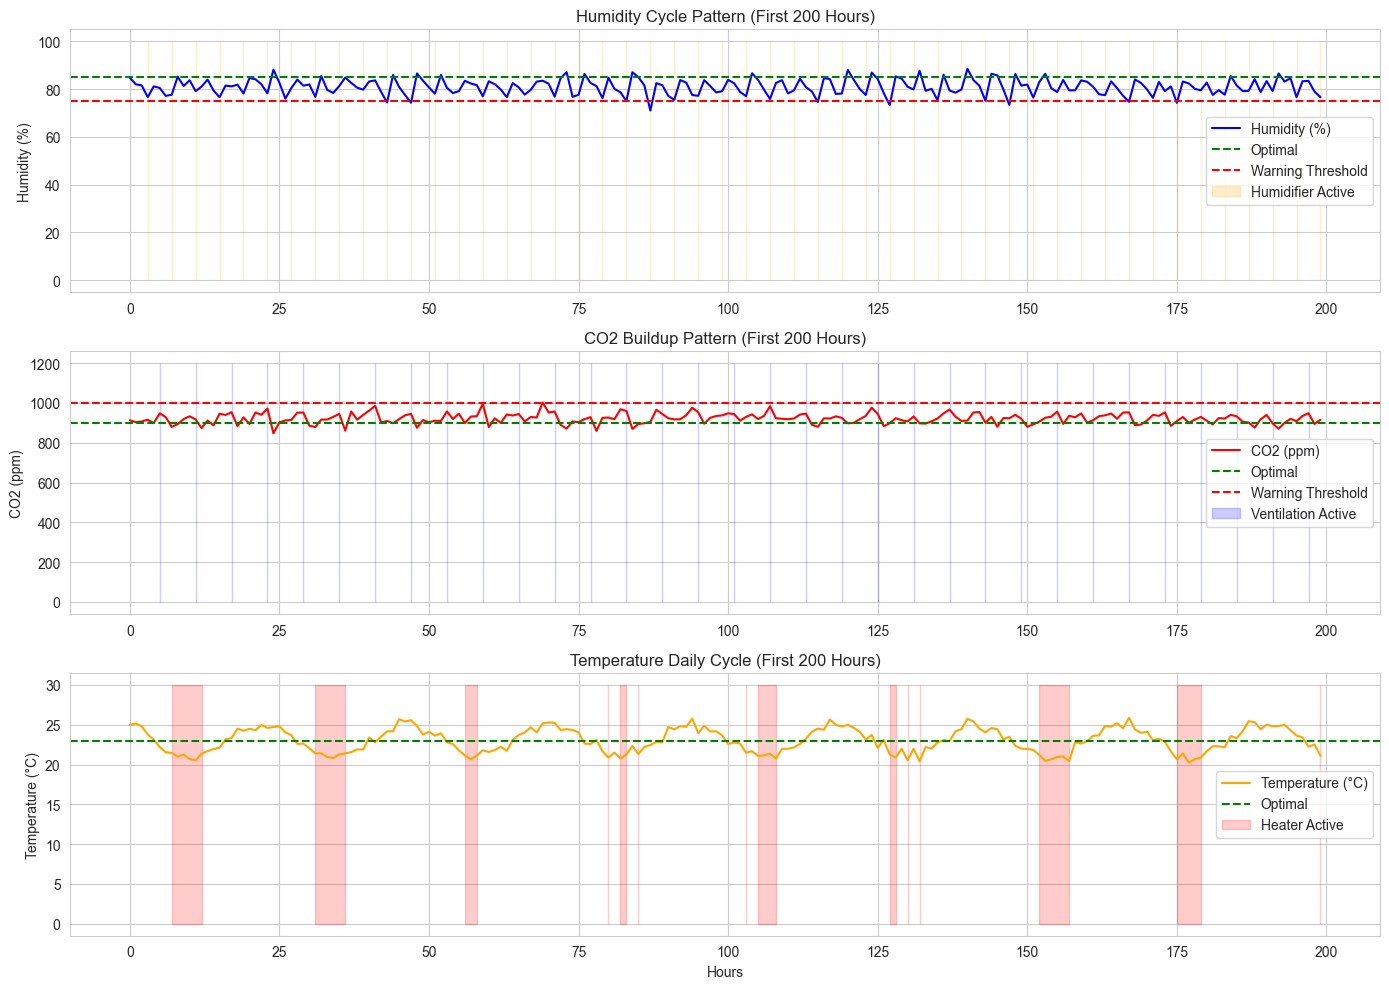


📊 Pattern Summary:
Humidifier activations: 250 times (25.0% of the time)
Ventilation activations: 166 times (16.6% of the time)
Heater activations: 205 times (20.5% of the time)


In [3]:
# Plot sensor patterns over time
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Humidity pattern
axes[0].plot(df.index[:200], df['humidity'][:200], label='Humidity (%)', color='blue')
axes[0].axhline(y=OPTIMAL_HUMIDITY, color='green', linestyle='--', label='Optimal')
axes[0].axhline(y=75, color='red', linestyle='--', label='Warning Threshold')
axes[0].fill_between(df.index[:200], 0, 100, where=df['activate_humidifier'][:200]==1, alpha=0.2, color='orange', label='Humidifier Active')
axes[0].set_ylabel('Humidity (%)')
axes[0].legend()
axes[0].set_title('Humidity Cycle Pattern (First 200 Hours)')

# CO2 pattern
axes[1].plot(df.index[:200], df['co2'][:200], label='CO2 (ppm)', color='red')
axes[1].axhline(y=OPTIMAL_CO2, color='green', linestyle='--', label='Optimal')
axes[1].axhline(y=1000, color='red', linestyle='--', label='Warning Threshold')
axes[1].fill_between(df.index[:200], 0, 1200, where=df['activate_ventilation'][:200]==1, alpha=0.2, color='blue', label='Ventilation Active')
axes[1].set_ylabel('CO2 (ppm)')
axes[1].legend()
axes[1].set_title('CO2 Buildup Pattern (First 200 Hours)')

# Temperature pattern
axes[2].plot(df.index[:200], df['temperature'][:200], label='Temperature (°C)', color='orange')
axes[2].axhline(y=OPTIMAL_TEMP, color='green', linestyle='--', label='Optimal')
axes[2].fill_between(df.index[:200], 0, 30, where=df['activate_heater'][:200]==1, alpha=0.2, color='red', label='Heater Active')
axes[2].set_ylabel('Temperature (°C)')
axes[2].set_xlabel('Hours')
axes[2].legend()
axes[2].set_title('Temperature Daily Cycle (First 200 Hours)')

plt.tight_layout()
plt.show()

print("\n📊 Pattern Summary:")
print(f"Humidifier activations: {df['activate_humidifier'].sum()} times ({df['activate_humidifier'].mean()*100:.1f}% of the time)")
print(f"Ventilation activations: {df['activate_ventilation'].sum()} times ({df['activate_ventilation'].mean()*100:.1f}% of the time)")
print(f"Heater activations: {df['activate_heater'].sum()} times ({df['activate_heater'].mean()*100:.1f}% of the time)")

## Step 3: Train Classification Models

We train 3 separate models to predict when each system should activate:
1. **Humidifier Model** - Predicts when to activate humidifier
2. **Ventilation Model** - Predicts when to activate ventilation
3. **Heater Model** - Predicts when to activate heater

In [4]:
# Prepare features
features = ['hour_of_day', 'temperature', 'humidity', 'co2']
X = df[features]

# Split data
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

# Model 1: Humidifier Activation
y_humidifier = df['activate_humidifier']
y_hum_train, y_hum_test = train_test_split(y_humidifier, test_size=0.2, random_state=42)

model_humidifier = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model_humidifier.fit(X_train, y_hum_train)

# Model 2: Ventilation Activation
y_ventilation = df['activate_ventilation']
y_vent_train, y_vent_test = train_test_split(y_ventilation, test_size=0.2, random_state=42)

model_ventilation = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model_ventilation.fit(X_train, y_vent_train)

# Model 3: Heater Activation
y_heater = df['activate_heater']
y_heat_train, y_heat_test = train_test_split(y_heater, test_size=0.2, random_state=42)

model_heater = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model_heater.fit(X_train, y_heat_train)

print("✅ Models trained successfully!")

✅ Models trained successfully!


## Step 4: Evaluate Model Performance

In [5]:
# Evaluate Humidifier Model
y_hum_pred = model_humidifier.predict(X_test)
print("=" * 60)
print("🌊 HUMIDIFIER MODEL PERFORMANCE")
print("=" * 60)
print(classification_report(y_hum_test, y_hum_pred, target_names=['No Action', 'Activate']))

# Evaluate Ventilation Model
y_vent_pred = model_ventilation.predict(X_test)
print("\n" + "=" * 60)
print("💨 VENTILATION MODEL PERFORMANCE")
print("=" * 60)
print(classification_report(y_vent_test, y_vent_pred, target_names=['No Action', 'Activate']))

# Evaluate Heater Model
y_heat_pred = model_heater.predict(X_test)
print("\n" + "=" * 60)
print("🔥 HEATER MODEL PERFORMANCE")
print("=" * 60)
print(classification_report(y_heat_test, y_heat_pred, target_names=['No Action', 'Activate']))

🌊 HUMIDIFIER MODEL PERFORMANCE
              precision    recall  f1-score   support

   No Action       0.94      0.98      0.96       151
    Activate       0.93      0.82      0.87        49

    accuracy                           0.94       200
   macro avg       0.94      0.90      0.92       200
weighted avg       0.94      0.94      0.94       200


💨 VENTILATION MODEL PERFORMANCE
              precision    recall  f1-score   support

   No Action       0.98      1.00      0.99       162
    Activate       1.00      0.89      0.94        38

    accuracy                           0.98       200
   macro avg       0.99      0.95      0.97       200
weighted avg       0.98      0.98      0.98       200


🔥 HEATER MODEL PERFORMANCE
              precision    recall  f1-score   support

   No Action       0.99      1.00      1.00       167
    Activate       1.00      0.97      0.98        33

    accuracy                           0.99       200
   macro avg       1.00      0.98   

## Step 5: Feature Importance Analysis

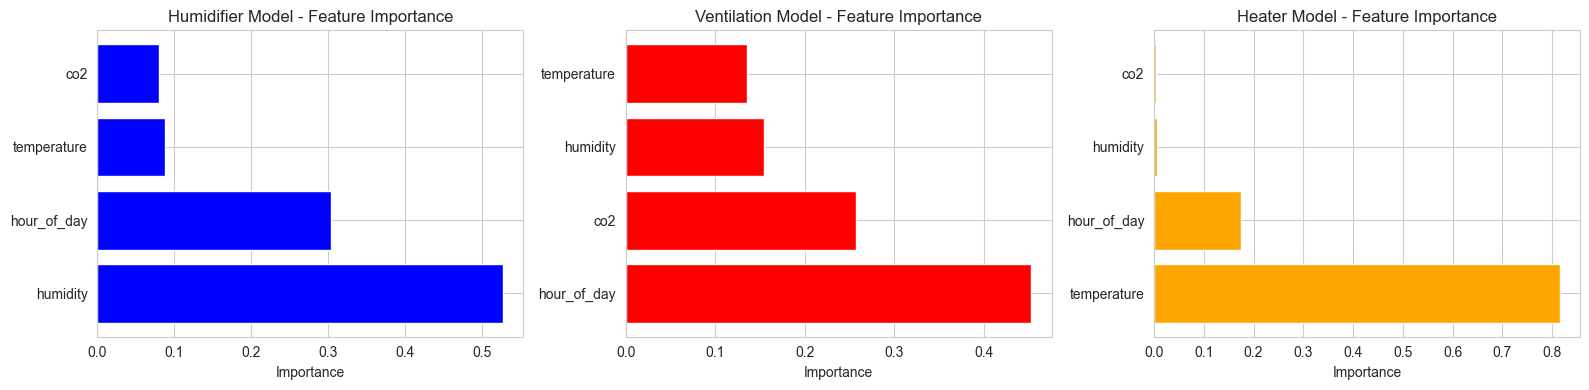

In [6]:
# Plot feature importance for all models
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Humidifier
importance_hum = pd.DataFrame({
    'feature': features,
    'importance': model_humidifier.feature_importances_
}).sort_values('importance', ascending=False)

axes[0].barh(importance_hum['feature'], importance_hum['importance'], color='blue')
axes[0].set_xlabel('Importance')
axes[0].set_title('Humidifier Model - Feature Importance')

# Ventilation
importance_vent = pd.DataFrame({
    'feature': features,
    'importance': model_ventilation.feature_importances_
}).sort_values('importance', ascending=False)

axes[1].barh(importance_vent['feature'], importance_vent['importance'], color='red')
axes[1].set_xlabel('Importance')
axes[1].set_title('Ventilation Model - Feature Importance')

# Heater
importance_heat = pd.DataFrame({
    'feature': features,
    'importance': model_heater.feature_importances_
}).sort_values('importance', ascending=False)

axes[2].barh(importance_heat['feature'], importance_heat['importance'], color='orange')
axes[2].set_xlabel('Importance')
axes[2].set_title('Heater Model - Feature Importance')

plt.tight_layout()
plt.show()

## Step 6: Test Predictive System

Simulate the system making predictions in real-time.

In [11]:
# Test with sample readings
test_scenarios = [
    {'hour_of_day': 14, 'temperature': 23.5, 'humidity': 78, 'co2': 920, 'description': 'Humidity dropping'},
    {'hour_of_day': 10, 'temperature': 22.0, 'humidity': 85, 'co2': 950, 'description': 'CO2 building up'},
    {'hour_of_day': 3, 'temperature': 20.5, 'humidity': 84, 'co2': 890, 'description': 'Temperature low at night'},
    {'hour_of_day': 16, 'temperature': 24.0, 'humidity': 86, 'co2': 905, 'description': 'All systems normal'},
]

print("\n" + "=" * 80)
print("🤖 PREDICTIVE MAINTENANCE SYSTEM TEST")
print("=" * 80)

for scenario in test_scenarios:
    input_data = pd.DataFrame([[
        scenario['hour_of_day'],
        scenario['temperature'],
        scenario['humidity'],
        scenario['co2']
    ]], columns=['hour_of_day', 'temperature', 'humidity', 'co2'])
    
    pred_hum = model_humidifier.predict(input_data)[0]
    pred_vent = model_ventilation.predict(input_data)[0]
    pred_heat = model_heater.predict(input_data)[0]
    
    print(f"\n📍 Scenario: {scenario['description']}")
    print(f"   Conditions: {scenario['temperature']}°C, {scenario['humidity']}% RH, {scenario['co2']} ppm CO2")
    print(f"   Hour: {scenario['hour_of_day']}:00")
    print("   Predicted Actions:")
    
    if pred_hum:
        print("   🌊 → Activate HUMIDIFIER (prevent humidity drop)")
    if pred_vent:
        print("   💨 → Activate VENTILATION (prevent CO2 spike)")
    if pred_heat:
        print("   🔥 → Activate HEATER (prevent temperature drop)")
    
    if not (pred_hum or pred_vent or pred_heat):
        print("   ✅ → No action needed (all systems stable)")

print("\n" + "=" * 80)


🤖 PREDICTIVE MAINTENANCE SYSTEM TEST

📍 Scenario: Humidity dropping
   Conditions: 23.5°C, 78% RH, 920 ppm CO2
   Hour: 14:00
   Predicted Actions:
   🌊 → Activate HUMIDIFIER (prevent humidity drop)

📍 Scenario: CO2 building up
   Conditions: 22.0°C, 85% RH, 950 ppm CO2
   Hour: 10:00
   Predicted Actions:
   ✅ → No action needed (all systems stable)

📍 Scenario: Temperature low at night
   Conditions: 20.5°C, 84% RH, 890 ppm CO2
   Hour: 3:00
   Predicted Actions:
   🔥 → Activate HEATER (prevent temperature drop)

📍 Scenario: All systems normal
   Conditions: 24.0°C, 86% RH, 905 ppm CO2
   Hour: 16:00
   Predicted Actions:
   ✅ → No action needed (all systems stable)



## Step 7: Save Models

In [10]:
# Save all three models
with open('predictive_maintenance_models.pkl', 'wb') as f:
    pickle.dump({
        'humidifier': model_humidifier,
        'ventilation': model_ventilation,
        'heater': model_heater,
        'features': features,
        'optimal_values': {
            'temperature': OPTIMAL_TEMP,
            'humidity': OPTIMAL_HUMIDITY,
            'co2': OPTIMAL_CO2
        }
    }, f)

print("\n✅ Models saved to 'predictive_maintenance_models.pkl'")
print("\nYou can now integrate these models into your Django views to:")
print("1. Predict when equipment should activate")
print("2. Prevent warning conditions before they occur")
print("3. Optimize equipment runtime and energy usage")


✅ Models saved to 'predictive_maintenance_models.pkl'

You can now integrate these models into your Django views to:
1. Predict when equipment should activate
2. Prevent warning conditions before they occur
3. Optimize equipment runtime and energy usage
